In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import scarf

scarf.configure_output(level="WARNING", progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    name="bastidas-ponce_4K_pancreas-d15_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(
    f"{dataset}/data.zarr",
    nthreads=4,
)
analysis_run = ds.pipeline.open(label="docs_default")
graph = analysis_run["connectivity_map"]

annotations = ds.cells.fetch("clusters", key="I")
source = annotations == "Ductal"
sink = np.isin(annotations, ["Alpha", "Beta", "Delta"])
if not source.any() or not sink.any():
    raise ValueError("Source and sink annotations must both be present")
source_sink_vector = np.zeros(len(annotations), dtype=float)
source_sink_vector[source] = -1.0 / source.sum()
source_sink_vector[sink] = 1.0 / sink.sum()

pseudotime_ref = ds.run_pseudotime_scoring(graph, ss_vec=source_sink_vector)
pseudotime = ds.load_pseudotime_scoring(pseudotime_ref)
sink_labels_ref = analysis_run["clusters"]
sink_labels = analysis_run.cells.fetch("clusters")

Downloading bucket files: 52847336 / 52847336 complete

Downloading bytes: 52847336 / 52847336 complete

In [2]:
terminal_labels = (
    pd.Series(
        pseudotime.values[pseudotime.valid],
        index=sink_labels[pseudotime.valid],
    )
    .groupby(level=0)
    .mean()
    .nlargest(2)
    .index.tolist()
)
if len(terminal_labels) != 2:
    raise ValueError("Fate mapping requires exactly two terminal labels in this example")
terminal_labels

[11, 3]

In [3]:
fate_ref = ds.run_fate_mapping(
    pseudotime_ref,
    sink_labels_ref,
    sinks=terminal_labels,
)
fate = ds.load_fate_mapping(fate_ref)
{
    "artifact": fate.ref,
    "pseudotime": fate.pseudotime,
    "sink labels": fate.sink_labels,
    "valid cells": int(fate.valid.sum()),
}

{'artifact': ArtifactRef(assay='RNA', kind='fate_map', artifact_id='1c472cefa6fe...'),
 'pseudotime': ArtifactRef(assay='RNA', kind='pseudotime', artifact_id='6f702b4feb50...'),
 'sink labels': (11, 3),
 'valid cells': 3696}

In [4]:
valid_probabilities = fate.values[fate.valid]
probability_summary = pd.DataFrame(
    valid_probabilities,
    columns=[str(label) for label in fate.sink_labels],
)
probability_summary["row-sum error"] = np.abs(
    probability_summary.sum(axis=1) - 1.0
)
probability_summary.agg(["min", "median", "max"])

,11,3,row-sum error
min,0.000000,0.000000,0.0
median,0.487185,0.512815,0.0
max,1.000000,1.000000,0.0


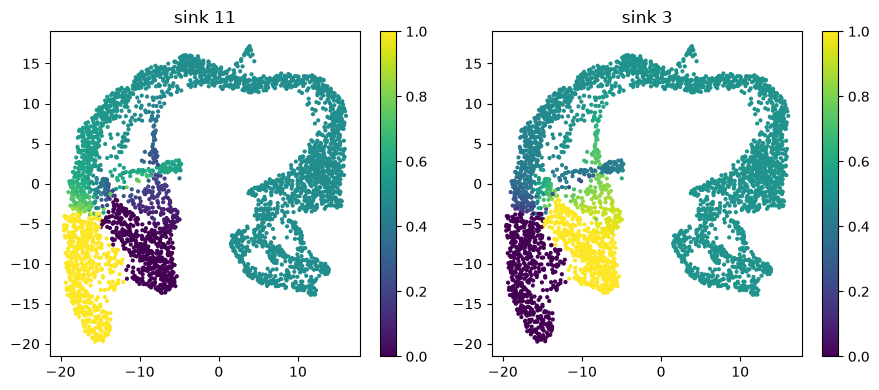

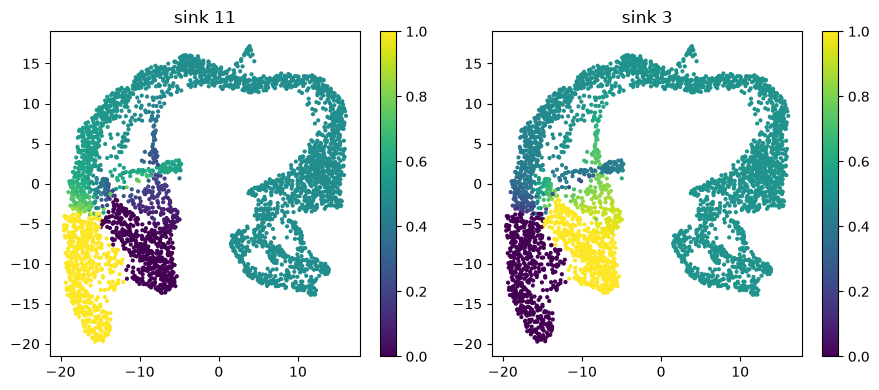

In [5]:
umap = np.asarray(ds.load_artifact(analysis_run["umap"])["values"][:])
figure, axes = plt.subplots(1, len(fate.sink_labels), figsize=(9, 4))
for index, label in enumerate(fate.sink_labels):
    axis = axes[index]
    points = axis.scatter(
        umap[fate.valid, 0],
        umap[fate.valid, 1],
        c=fate.values[fate.valid, index],
        s=4,
    )
    axis.set_title(f"sink {label}")
    figure.colorbar(points, ax=axis)
figure.tight_layout()
figure